# Defi EquiAlgo - rapport d'audit

Audit d'equite du modele d'octroi de bourses : **mesure du biais**, **metriques d'equite retenues et
justification**, **variables proxys**.

Carnets associes :
- `analyse_donnees.ipynb` : distributions et correlations ;
- `model_corrige.ipynb` : cible contrefactuelle, front de Pareto et modele corrige.

Fonctions reutilisees : `analyse.py` (metriques, bootstrap, tranches) et `cible.py` (modele de decision,
cible, modele corrige).

## 0. Resume

| Constat | Valeur (IC 95 %) |
|---|---|
| Ecart d'octroi du comite, Centre moins Eloignee | 21 points (19 a 23) |
| Part de cet ecart **inexpliquee** par le profil (cote R, revenu, heures...) | 18 points (15 a 21) |
| Ecart d'egalite des chances du modele de production, contre `decision_octroi` | 0.06 (0.01 a 0.11) |
| Le meme ecart, contre la reference de merite (scoreur : 0.270) | **0.26** (0.22 a 0.31) |
| Apres correction, contre les references independantes | 0.04 (variante revenu) et -0.04 (cote R seule) |

1. Le comite penalise les regions eloignees : la cote R plus faible n'explique que 3 points sur 21.
2. Le modele de production reproduit cette penalite. L'audit de la baseline ne la voit pas, car il la
   mesure contre l'etiquette biaisee elle-meme. La region est portee par des proxys (code postal,
   distance, heures, revenu) : la retirer ne suffit pas.
3. Le modele corrige, sans region ni code postal, comble 83 a 87 % de l'ecart contre les references
   independantes, a budget constant (40 %).

Les chiffres sont recalcules par la derniere cellule du carnet (section 7).

## 1. Perimetre et methode

**Ce qu'on audite.**
1. Le **comite** historique, `decision_octroi`, sur 10 000 dossiers.
2. Le **modele de production** : la foret aleatoire de `baseline_model.ipynb`, entrainee sur toutes les
   colonnes, y compris la region.
3. Le **modele corrige** : la regression logistique sans region ni code postal, entrainee sur la cible
   individuelle (`model_corrige.ipynb` §3).

**Groupes.** Centre (Montreal, Capitale-Nationale) et Eloignee (Bas-Saint-Laurent, Cote-Nord,
Gaspesie-Iles-de-la-Madeleine).

**Reference de merite.** `decision_octroi` est biaise et l'etalon du jury est cache. La reference est
la decision que le comite aurait prise en traitant chaque candidat comme un candidat du Centre
(`model_corrige.ipynb` §1). Elle est validee empiriquement : contre elle, l'ecart d'egalite des chances
du modele de production vaut 0.264, contre 0.270 annonce par le scoreur. Deux references
alternatives servent a la triangulation : la cote R seule, et le contrefactuel qui neutralise aussi le
revenu.

**Protocole.** Meme decoupage 70/30 que la baseline (stratifie, `random_state=42`). Les modeles sont
ajustes sur `train` et mesures sur `test`. Les intervalles de confiance a 95 % sont obtenus par
bootstrap, avec un reechantillonnage stratifie par groupe.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder

from analyse import (importance_permutation, intervalle_bootstrap, metriques_equite,
                     tableau_tranches, tracer_importances)
from cible import (VARIABLES_MODELE, ajouter_eloignee, ajuster_modele_decision, cible_individuelle,
                   coefficients, entrainer_modele_cible, octroi_par_tranche_r, octroi_top_k,
                   score_contrefactuel)

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)

demandes = ajouter_eloignee(pd.read_csv('data/donnees_demandes.csv'))
candidats = ajouter_eloignee(pd.read_csv('data/candidats_evaluation.csv'))
groupe = np.where(demandes['eloignee'] == 1, 'Eloignee', 'Centre')
groupe_cand = np.where(candidats['eloignee'] == 1, 'Eloignee', 'Centre')

train, test = train_test_split(
    demandes, test_size=0.3, random_state=42, stratify=demandes['decision_octroi']
)
groupe_tr, groupe_te = groupe[train.index], groupe[test.index]
y_comite = test['decision_octroi'].to_numpy()

# Palette de reference : Centre bleu, Eloignee orange ; textes en encre neutre.
COULEURS_GROUPE = {'Centre': '#2a78d6', 'Eloignee': '#eb6834'}
ENCRE, ENCRE_SECONDAIRE, GRILLE = '#0b0b0b', '#52514e', '#e4e3df'


def styliser(ax, titre=None):
    """Axes discrets : grille legere, sans cadre haut/droite."""
    if titre:
        ax.set_title(titre, color=ENCRE, fontsize=11, loc='left')
    ax.grid(color=GRILLE, lw=0.8)
    ax.set_axisbelow(True)
    for cote in ['top', 'right']:
        ax.spines[cote].set_visible(False)
    ax.tick_params(colors=ENCRE_SECONDAIRE)
    return ax

In [2]:
# Les trois modeles audites et les references de merite, sur le meme decoupage.
CATEGORIELLES_RF = ['programme_etudes', 'region_administrative', 'code_postal_3']


def encoder_rf(df_entrainement, df_cible, exclues=()):
    """Encodage de la baseline (one-hot, colonnes alignees), sans les colonnes `exclues`."""
    retirer = ['id_candidat', 'decision_octroi', 'eloignee', *exclues]
    categorielles = [c for c in CATEGORIELLES_RF if c not in exclues]
    X = pd.get_dummies(df_entrainement.drop(columns=retirer), columns=categorielles)
    Xc = pd.get_dummies(df_cible.drop(columns=retirer), columns=categorielles
                        ).reindex(columns=X.columns, fill_value=0)
    return X, Xc


def entrainer_rf(exclues=()):
    """RF de production ajuste sur train ; retourne (modele, X_test, decisions sur test)."""
    X_tr, X_te = encoder_rf(train, test, exclues)
    rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42)
    rf.fit(X_tr, train['decision_octroi'])
    return rf, X_te, rf.predict(X_te)


modele_valid = ajuster_modele_decision(train)
references = {
    'contrefactuel': octroi_top_k(score_contrefactuel(modele_valid, test)),
    'contrefactuel + revenu': octroi_top_k(score_contrefactuel(
        modele_valid, test, neutraliser=['revenu_familial_estime'], reference=train)),
    'cote R seule': octroi_top_k(test['cote_r_equivalent']),
}
y_ref = references['contrefactuel']

rf, X_te_rf, decisions_rf = entrainer_rf()
modele_corrige = entrainer_modele_cible(train, cible_individuelle(modele_valid, train))
decisions_corrige = octroi_top_k(modele_corrige.predict_proba(test[VARIABLES_MODELE])[:, 1])

## 2. Mesure du biais

### 2.1 Le comite

**Decomposition de l'ecart.** Le modele de decision (regression logistique avec un indicateur
de region) reproduit le comite (AUC 0.954). On predit le taux d'octroi des candidats eloignes s'ils
avaient ete traites comme des candidats du Centre :
- la difference avec le taux du **Centre** est la part due au **profil** (cote R, revenu, heures...) ;
- la difference avec leur taux **observe** est la part **inexpliquee** par le profil, attribuable a
  la region.

Le modele est reajuste a chaque tirage bootstrap (200 tirages).

In [3]:
def decomposer_ecart(indices):
    """Ecart d'octroi du comite, decompose en part due au profil et part inexpliquee."""
    s, g = demandes.iloc[indices], groupe[indices]
    modele = ajuster_modele_decision(s)
    centre = s.loc[g == 'Centre', 'decision_octroi'].mean()
    eloignee = s.loc[g == 'Eloignee', 'decision_octroi'].mean()
    eloignee_cf = score_contrefactuel(modele, s[g == 'Eloignee'], retrait=1).mean()
    return {'ecart_total': centre - eloignee,
            'part_profil': centre - eloignee_cf,
            'part_inexpliquee': eloignee_cf - eloignee}


decomposition = intervalle_bootstrap(decomposer_ecart, np.arange(len(demandes)), strates=groupe, n=200)
print(decomposition.round(3))
print()
print('Taux d\'octroi par tranche de cote R (comite)')
print(octroi_par_tranche_r(demandes, demandes['decision_octroi']).round(3))

                  estimation    bas   haut
ecart_total            0.211  0.193  0.230
part_profil            0.030  0.004  0.061
part_inexpliquee       0.180  0.153  0.205

Taux d'octroi par tranche de cote R (comite)
                   Centre  Eloignee
cote_r_equivalent                  
(0, 26]             0.020     0.005
(26, 27]            0.161     0.038
(27, 28]            0.316     0.100
(28, 29]            0.593     0.256
(29, 30]            0.849     0.568
(30, 32]            0.958     0.831
(32, 45]            0.998     0.986


**Lecture.**
- L'ecart du comite est de **21 points** (IC 95 % : 19 a 23).
- Seuls **3 points** (IC : 0.4 a 6) s'expliquent par le profil des candidats, y compris la cote R plus
  faible en region. Les **18 points** restants (IC : 15 a 21) ne s'expliquent par aucune variable de
  merite : ils sont attribuables a la region.
- A cote R egale, l'ecart est massif : entre 28 et 29, le comite accorde a 59 % des candidats du Centre
  contre 26 % des candidats eloignes.
- L'ecart est uniforme entre les trois regions eloignees et entre les programmes
  (`analyse_donnees.ipynb` §4) : c'est une penalite constante liee a la region.

### 2.2 Le modele de production

Le RF reproduit le comite. On le mesure contre deux etiquettes : `decision_octroi`, comme dans la
baseline, et la reference de merite.

In [4]:
audit_rf = pd.concat({
    'contre decision_octroi': intervalle_bootstrap(metriques_equite, y_comite, decisions_rf, groupe_te,
                                                   strates=groupe_te),
    'contre la reference de merite': intervalle_bootstrap(metriques_equite, y_ref, decisions_rf, groupe_te,
                                                          strates=groupe_te),
}, axis=1)
print(audit_rf.round(3))

                        contre decision_octroi               contre la reference de merite              
                                    estimation    bas   haut                    estimation    bas   haut
taux_selection_Centre                    0.459  0.435  0.481                         0.459  0.435  0.481
taux_selection_Eloignee                  0.271  0.247  0.298                         0.271  0.247  0.298
ecart_parite                             0.188  0.155  0.221                         0.188  0.155  0.221
ecart_egalite_chances                    0.063  0.014  0.111                         0.264  0.220  0.308
ecart_fpr                                0.019 -0.006  0.046                         0.093  0.076  0.111
ecart_precision                          0.093  0.046  0.141                        -0.119 -0.142 -0.097
exactitude                               0.881  0.869  0.892                         0.917  0.907  0.927


**Lecture.**
- Contre `decision_octroi`, le RF parait presque equitable : l'ecart d'egalite des chances n'est que
  de 0.06. C'est la mesure de la baseline, et elle ne verifie que la **fidelite au comite**.
- Contre la reference de merite, l'ecart est de **0.26** (IC : 0.22 a 0.31). Parmi les candidats
  meritants, ceux des regions eloignees ont 26 points de moins de chances d'obtenir la bourse. L'IC
  contient la valeur de 0.270 annoncee par le scoreur.
- L'ecart de parite (0.19) est le meme quelle que soit l'etiquette, puisqu'il ne depend que des
  decisions.

### 2.3 Analyse par tranches

Taux de selection et TPR contre la reference, pour le RF et le modele corrige. La TPR d'une tranche
sans meritant est laissee vide. Les tranches de moins de 100 dossiers sont signalees par `*`.

In [5]:
def comparer_tranches(tranches):
    """Tableau par tranche du RF et du modele corrige, cote a cote."""
    tableau = pd.concat({
        'RF': tableau_tranches(y_ref, decisions_rf, tranches),
        'corrige': tableau_tranches(y_ref, decisions_corrige, tranches)[['taux_selection', 'tpr']],
    }, axis=1)
    tableau[('', 'faible effectif')] = np.where(tableau[('RF', 'effectif')] < 100, '*', '')
    return tableau


tranche_r = pd.cut(test['cote_r_equivalent'], [0, 26, 27, 28, 29, 30, 32, 45]).astype(str).rename('cote R')
g_te = pd.Series(groupe_te, index=test.index, name='groupe')

print(comparer_tranches(test['region_administrative'].rename('region')).round(3), end='\n\n')
print(comparer_tranches(pd.concat([test['programme_etudes'].rename('programme'), g_te], axis=1)).round(3), end='\n\n')
print(comparer_tranches(pd.concat([tranche_r, g_te], axis=1)).round(3), end='\n\n')
print(comparer_tranches(pd.concat([test['premiere_generation_universitaire'].rename('premiere generation'),
                                   g_te], axis=1)).round(3))

                                    RF                                        corrige                       
                              effectif meritants taux_selection    tpr taux_selection    tpr faible effectif
region                                                                                                      
Bas-Saint-Laurent                400.0     147.0          0.272  0.741          0.368  1.000                
Capitale-Nationale               611.0     256.0          0.458  0.961          0.421  0.996                
Cote-Nord                        364.0     136.0          0.261  0.699          0.374  0.985                
Gaspesie-Iles-de-la-Madeleine    461.0     183.0          0.278  0.699          0.395  0.995                
Montreal                        1164.0     478.0          0.459  0.985          0.411  0.996                

                                 RF                                        corrige                       
                     

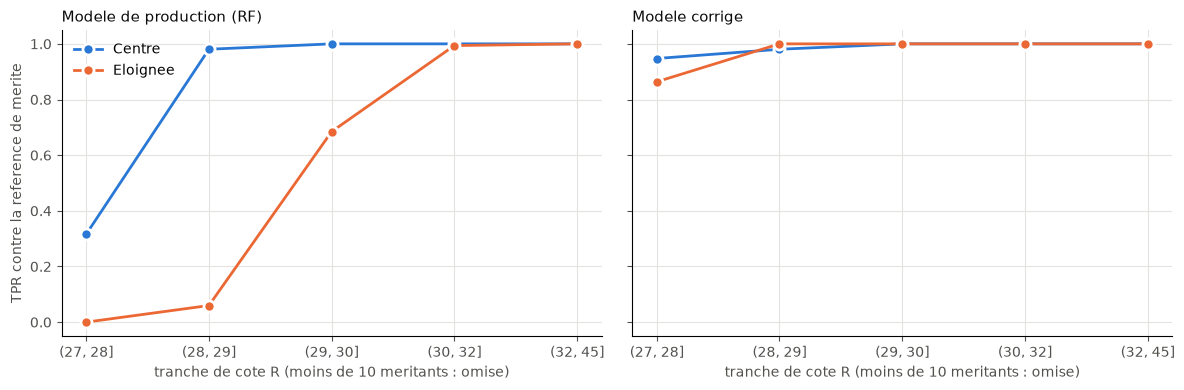

In [6]:
# TPR par tranche de cote R : RF contre modele corrige.
def tpr_par_tranche_r(decisions, min_meritants=10):
    """TPR par tranche de cote R et groupe ; tranches de moins de `min_meritants` meritants masquees."""
    tableau = tableau_tranches(y_ref, decisions, pd.concat([tranche_r, g_te], axis=1))
    return tableau['tpr'].where(tableau['meritants'] >= min_meritants).unstack()


tpr_r = {nom: tpr_par_tranche_r(d)
         for nom, d in [('Modele de production (RF)', decisions_rf), ('Modele corrige', decisions_corrige)]}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (nom, tpr) in zip(axes, tpr_r.items()):
    tpr = tpr.dropna(how='all')
    for g, couleur in COULEURS_GROUPE.items():
        ax.plot(range(len(tpr)), tpr[g], '-o', color=couleur, lw=2, ms=8, mec='white', mew=2, label=g)
    ax.set_xticks(range(len(tpr)), tpr.index)
    ax.set_xlabel('tranche de cote R (moins de 10 meritants : omise)', color=ENCRE_SECONDAIRE)
    styliser(ax, nom)
axes[0].set_ylabel('TPR contre la reference de merite', color=ENCRE_SECONDAIRE)
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

**Lecture.**
- **Par region** : avec le RF, la TPR est de 96 a 99 % dans les deux centres et de 70 a 74 % dans
  chacune des trois regions eloignees. Aucune region eloignee n'echappe au biais. Avec le modele
  corrige, elle est de 98.5 a 100 % partout.
- **Par cote R** : le biais du RF se concentre pres du seuil. Entre 28 et 29, il accorde la bourse a
  98 % des meritants du Centre, contre 6 % des meritants eloignes ; entre 29 et 30, 100 % contre 68.5 %.
  Loin du seuil (cote R superieure a 30), les deux groupes sont traites de la meme facon.
- Le modele corrige n'est pas parfait pres du seuil : entre 27 et 28, sa TPR est de 95 % au Centre et de
  86 % en region, sur seulement 19 et 22 meritants.
- **Par programme et par premiere generation** : avec le RF, la TPR des candidats eloignes est de 65 a
  81 % selon le programme, contre 95 a 99 % au Centre. Apres correction, elle est d'au moins 97.9 %
  dans chaque croisement : la correction ne cree pas de nouveau sous-groupe defavorise.
- Les tranches de cote R de 32 et plus en region comptent moins de 100 dossiers : leurs taux sont
  moins precis.

## 3. Metriques d'equite et justification

| Metrique | Definition | Ce qu'elle protege |
|---|---|---|
| Parite demographique | meme taux d'octroi dans les deux groupes | l'egalite des resultats, independamment du merite |
| **Egalite des chances** | meme TPR : parmi les meritants, meme chance d'obtenir la bourse | les candidats meritants |
| Egalite des chances egalisee | meme TPR **et** meme FPR | les meritants et les non-meritants |
| Parite predictive | meme precision : parmi les octrois, meme part de meritants | la fiabilite d'une decision positive |

Les valeurs du RF sont dans le tableau de la section 2.2 (`ecart_parite`, `ecart_egalite_chances`,
`ecart_fpr`, `ecart_precision`).

In [7]:
# Incompatibilite : les taux de merite different entre groupes.
taux_merite = pd.Series(y_ref).groupby(groupe_te).mean()
print('Taux de meritants dans la reference :', taux_merite.round(3).to_dict())

# (a) Classifieur parfait : egalite des chances exacte.
# (b) Parite imposee : 40 % d'octroi dans chaque groupe, selon le score du modele corrige.
score_corrige = modele_corrige.predict_proba(test[VARIABLES_MODELE])[:, 1]
decisions_parite = np.zeros(len(test), dtype=int)
for g in ['Centre', 'Eloignee']:
    masque = groupe_te == g
    decisions_parite[masque] = octroi_top_k(score_corrige[masque], 0.40)

print(pd.DataFrame({
    'classifieur parfait': metriques_equite(y_ref, y_ref, groupe_te),
    'parite imposee': metriques_equite(y_ref, decisions_parite, groupe_te),
}).T[['ecart_parite', 'ecart_egalite_chances', 'ecart_fpr', 'ecart_precision', 'exactitude']].round(3))

Taux de meritants dans la reference : {'Centre': 0.414, 'Eloignee': 0.38}
                     ecart_parite  ecart_egalite_chances  ecart_fpr  ecart_precision  exactitude
classifieur parfait         0.033                  0.000      0.000            0.000       1.000
parite imposee              0.000                 -0.033     -0.032            0.049       0.984


**Lecture.** Selon la reference, 41.4 % des candidats du Centre meritent la bourse, contre 38.0 %
des candidats eloignes (cote R moyenne plus faible). Les deux criteres ne peuvent donc pas etre nuls
ensemble :
- un classifieur **parfait** a un ecart d'egalite des chances nul, mais un ecart de parite de 3.3
  points, egal a la difference de taux de merite ;
- imposer la **parite** (40 % d'octroi dans chaque groupe) annule l'ecart de parite mais cree un
  ecart d'egalite des chances de -3.3 points : des candidats eloignes moins meritants passent devant
  des candidats du Centre meritants.

**Choix : l'egalite des chances.**
1. **C'est une bourse au merite** : la question equitable est de savoir si un candidat meritant a la
   meme chance d'etre retenu, quelle que soit sa region. La parite demographique imposerait un quota
   independant du merite.
2. **Le budget est fixe** : chaque octroi non merite retire une bourse a un candidat meritant. La
   parite deplacerait des bourses sans lien avec le merite.
3. **C'est la metrique du scoreur** (20 points sur 35), et la plus lisible pour un candidat refuse.
4. **L'egalite des chances egalisee** (TPR et FPR) est plus exigeante. Avec un budget fixe et des taux
   de merite proches, l'ecart de FPR suit celui de TPR : on le surveille sans en faire une contrainte.

**Limite.** L'egalite des chances exige une etiquette de merite, et `decision_octroi` est precisement
l'etiquette biaisee. La mesurer contre `decision_octroi` (comme la baseline) revient a verifier la
fidelite au comite, ce qui explique l'ecart de 0.06 en 2.2. D'ou la reference contrefactuelle, validee
par le chiffre du scoreur et triangulee avec deux references alternatives (section 5).

## 4. Variables proxys

### 4.1 Predictibilite de la region

AUC (validation croisee a 5 plis) d'un modele de gradient boosting qui predit `eloignee` a partir d'une
seule variable, puis de plusieurs. 0.5 : aucune information sur la region ; 1.0 : region determinee.

toutes sauf code postal                0.998
toutes sauf code postal et distance    0.841
dtype: float64


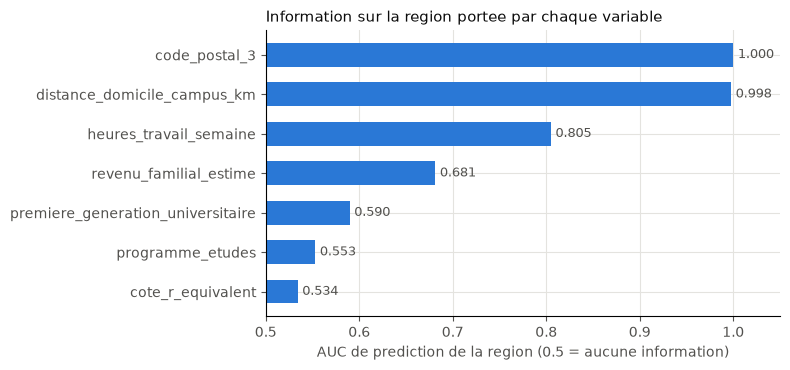

In [8]:
VARIABLES = ['cote_r_equivalent', 'revenu_familial_estime', 'heures_travail_semaine',
             'distance_domicile_campus_km', 'premiere_generation_universitaire',
             'programme_etudes', 'code_postal_3']


def auc_prediction_region(colonnes):
    """AUC en validation croisee d'un modele qui predit `eloignee` a partir de `colonnes`."""
    categorielles = [c for c in colonnes if c in ('programme_etudes', 'code_postal_3')]
    pretraitement = ColumnTransformer(
        [('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorielles)],
        remainder='passthrough')
    modele = make_pipeline(pretraitement, HistGradientBoostingClassifier(max_iter=100, random_state=42))
    return cross_val_score(modele, demandes[colonnes], demandes['eloignee'], cv=5, scoring='roc_auc').mean()


auc_region = pd.Series({v: auc_prediction_region([v]) for v in VARIABLES}).sort_values()
auc_combinaisons = pd.Series({
    'toutes sauf code postal': auc_prediction_region([v for v in VARIABLES if v != 'code_postal_3']),
    'toutes sauf code postal et distance': auc_prediction_region(
        [v for v in VARIABLES if v not in ('code_postal_3', 'distance_domicile_campus_km')]),
})
print(auc_combinaisons.round(3))

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(auc_region.index, auc_region.values - 0.5, left=0.5, color=COULEURS_GROUPE['Centre'], height=0.6)
for i, v in enumerate(auc_region.values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9, color=ENCRE_SECONDAIRE)
ax.set_xlim(0.5, 1.05)
ax.set_xlabel('AUC de prediction de la region (0.5 = aucune information)', color=ENCRE_SECONDAIRE)
styliser(ax, 'Information sur la region portee par chaque variable')
plt.tight_layout()
plt.show()

**Lecture.**
- `code_postal_3` (AUC 1.000) et la distance (0.998) **determinent** la region.
- Les heures travaillees (0.81) et le revenu (0.68) en portent une part importante.
- La premiere generation, le programme et la cote R n'en portent presque pas (0.53 a 0.59).
- Meme sans code postal ni distance, les autres variables predisent encore la region avec une AUC
  de 0.84.

### 4.2 Equite par ignorance : retirer les proxys suffit-il ?

On etend la section 5 de la baseline. Le RF est reentraine en retirant cumulativement la region, le
code postal, la distance, les heures et le revenu.

In [9]:
ETAPES = ['region_administrative', 'code_postal_3', 'distance_domicile_campus_km',
          'heures_travail_semaine', 'revenu_familial_estime']

COURTS = {'region_administrative': 'region', 'code_postal_3': 'code postal',
          'distance_domicile_campus_km': 'distance', 'heures_travail_semaine': 'heures',
          'revenu_familial_estime': 'revenu'}

lignes = {}
for k in range(len(ETAPES) + 1):
    exclues = ETAPES[:k]
    _, _, d = entrainer_rf(exclues)
    contre_ref, contre_comite = metriques_equite(y_ref, d, groupe_te), metriques_equite(y_comite, d, groupe_te)
    etiquette = 'toutes les colonnes' if not exclues else '- ' + ', '.join(COURTS[c] for c in exclues)
    lignes[etiquette] = {
        'ecart_parite': contre_ref['ecart_parite'],
        'ecart_egalite_chances (reference)': contre_ref['ecart_egalite_chances'],
        'exactitude (reference)': contre_ref['exactitude'],
        'ecart_egalite_chances (comite)': contre_comite['ecart_egalite_chances'],
        'exactitude (comite)': contre_comite['exactitude'],
    }
ignorance = pd.DataFrame(lignes).T
print(ignorance.round(3))

                                                 ecart_parite  ecart_egalite_chances (reference)  exactitude (reference)  ecart_egalite_chances (comite)  exactitude (comite)
toutes les colonnes                                     0.188                              0.264                   0.917                           0.063                0.881
- region                                                0.180                              0.251                   0.922                           0.042                0.884
- region, code postal                                   0.173                              0.224                   0.929                           0.024                0.879
- region, code postal, distance                         0.110                              0.116                   0.949                          -0.048                0.871
- region, code postal, distance, heures                 0.122                              0.134                   0.937          

**Lecture.**
- Retirer la region puis le code postal ne change presque rien : l'ecart de parite passe de 0.188 a
  0.180 puis 0.173 (les chiffres de la baseline), et l'ecart d'egalite des chances de 0.264 a 0.224.
- Retirer la **distance** divise l'ecart par deux (0.116) : c'est le proxy le plus actif.
- Retirer ensuite les heures le fait remonter legerement (0.134) : elles portaient aussi un critere
  reel, que le modele compense par d'autres variables.
- Retirer aussi le revenu le ramene a 0.073, mais en jetant de l'information : l'exactitude
  contre la reference retombe a 0.918, et l'ecart reste non nul. Le modele apprend toujours a
  reproduire un comite biaise.
- Retirer des colonnes ne corrige pas une **etiquette** biaisee. Il faut corriger la cible
  (`model_corrige.ipynb`), pas seulement les variables.

### 4.3 Proxys purs ou criteres legitimes ?

Une variable peut porter la region **et** un effet propre sur le merite. Pour les distinguer, on ajuste
le modele de decision **dans chaque groupe** : un effet qui persiste a l'interieur d'un groupe n'est pas
un simple reflet de la region.

                                        Centre  Eloignee  AUC prediction region
num__cote_r_equivalent                   4.043     4.064                  0.534
num__distance_domicile_campus_km         0.070     0.102                  0.998
num__heures_travail_semaine              0.624     0.663                  0.805
num__premiere_generation_universitaire   0.002    -0.056                  0.590
num__revenu_familial_estime              0.708     0.734                  0.681

Importance par permutation du RF de production (baisse d'AUC contre decision_octroi)
                                   moyenne  ecart_type
cote_r_equivalent                   0.3776      0.0080
revenu_familial_estime              0.0119      0.0009
heures_travail_semaine              0.0082      0.0007
distance_domicile_campus_km         0.0037      0.0007
region_administrative               0.0036      0.0007
premiere_generation_universitaire   0.0000      0.0001
programme_etudes                   -0.0003      0

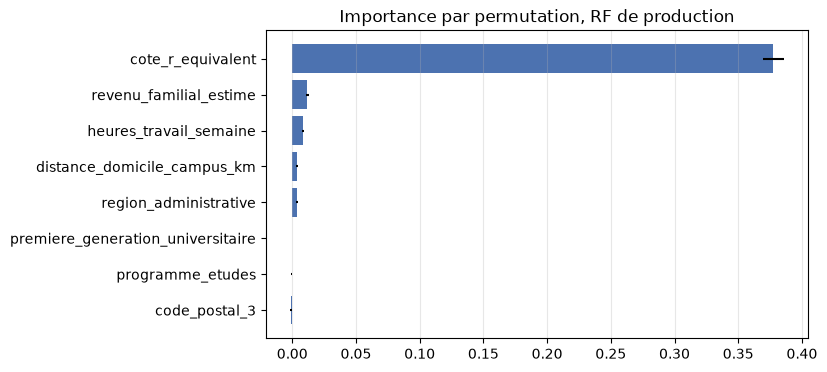

In [10]:
effets_intra_groupe = pd.DataFrame({
    g: coefficients(ajuster_modele_decision(demandes[groupe == g])) for g in ['Centre', 'Eloignee']
}).drop(index='num__eloignee').filter(like='num__', axis=0)
effets_intra_groupe['AUC prediction region'] = auc_region.reindex(
    [n.split('__')[1] for n in effets_intra_groupe.index]).to_numpy()
print(effets_intra_groupe.round(3))

print()
print('Importance par permutation du RF de production (baisse d\'AUC contre decision_octroi)')
importances = importance_permutation(rf, X_te_rf, y_comite)
print(importances.round(4))
tracer_importances(importances, 'Importance par permutation, RF de production')
plt.show()

**Lecture.**

| Variable | Porte la region | Effet propre dans chaque groupe | Statut |
|---|---|---|---|
| `code_postal_3` | totalement (AUC 1.000) | aucun (non utilise par le modele de decision) | **proxy pur** |
| `distance_domicile_campus_km` | presque totalement (0.998) | tres faible (0.07 et 0.10) | **proxy pur** |
| `heures_travail_semaine` | fortement (0.81) | net (0.62 et 0.66) | proxy **et** critere |
| `revenu_familial_estime` | moyennement (0.68) | net (0.71 et 0.73) | proxy **et** critere |
| `premiere_generation_universitaire` | faiblement (0.59) | negligeable (0.00 et -0.06) | neutre |

- Le comite valorise les heures travaillees et, plus surprenant, un **revenu eleve**, dans les deux
  groupes. Ce ne sont pas de simples reflets de la region. Les retirer (equite par ignorance) supprime
  aussi un critere de decision reel ; les garder transmet une partie de l'ecart regional.
- Favoriser les revenus eleves va a l'encontre de l'objectif habituel d'une bourse. C'est une question
  de **gouvernance**, hors du perimetre statistique : la variante « contrefactuel + revenu » de
  `model_corrige.ipynb` mesure l'effet de ce choix.
- **Paradoxe de Simpson** (`analyse_donnees.ipynb` §5) : sur l'ensemble des donnees, les heures ne sont
  pas correlees a la decision (-0.02), alors qu'elles l'augmentent dans chaque groupe. Un audit par
  correlations globales ne le verrait pas.
- Dans le RF, region, distance, heures et revenu ont chacun une importance faible par rapport a la
  cote R. Le biais est **diffus** : aucune variable unique ne le porte, d'ou l'echec de l'equite par
  ignorance.

## 5. Avant / apres correction

Ecart d'egalite des chances contre les trois references de merite. La reference contrefactuelle est
partiellement circulaire pour le modele corrige, qui en est derive : les deux references alternatives
servent de controle.

In [11]:
def ecarts_toutes_references(y_contrefactuel, y_revenu, y_cote_r, decisions, groupes):
    """Ecart d'egalite des chances contre chaque reference de merite."""
    return {nom: metriques_equite(y, decisions, groupes)['ecart_egalite_chances']
            for nom, y in zip(references, [y_contrefactuel, y_revenu, y_cote_r])}


avant_apres = pd.concat({
    nom: intervalle_bootstrap(
        lambda a, b, c, d, g: ecarts_toutes_references(a, b, c, d, g),
        *references.values(), decisions, groupe_te, strates=groupe_te)
    for nom, decisions in [('RF de production', decisions_rf), ('modele corrige', decisions_corrige)]
}, axis=1)
avant_apres[('', 'part de l\'ecart comblee')] = (
    1 - avant_apres[('modele corrige', 'estimation')].abs() / avant_apres[('RF de production', 'estimation')])
print(avant_apres.round(3))
print()
print(pd.DataFrame({
    'RF de production': metriques_equite(y_ref, decisions_rf, groupe_te),
    'modele corrige': metriques_equite(y_ref, decisions_corrige, groupe_te),
}).round(3))

                       RF de production               modele corrige                                      
                             estimation    bas   haut     estimation    bas   haut part de l'ecart comblee
contrefactuel                     0.264  0.220  0.308          0.002 -0.006  0.011                   0.991
contrefactuel + revenu            0.333  0.292  0.377          0.044  0.016  0.073                   0.868
cote R seule                      0.238  0.196  0.280         -0.040 -0.068 -0.008                   0.834

                         RF de production  modele corrige
taux_selection_Centre               0.459           0.414
taux_selection_Eloignee             0.271           0.380
ecart_parite                        0.188           0.034
ecart_egalite_chances               0.264           0.002
ecart_fpr                           0.093           0.001
ecart_precision                    -0.119          -0.001
exactitude                          0.917           0.996


In [12]:
# Soumission : predictions.csv (ecrit par model_corrige.ipynb §3.3).
soumission = pd.read_csv('predictions.csv')
assert (soumission['id_candidat'] == candidats['id_candidat']).all(), 'identifiants differents'
assert set(soumission['decision_octroi']) <= {0, 1}
taux = soumission['decision_octroi'].mean()
print(f'{len(soumission)} lignes, taux d\'octroi {taux:.1%}', '- budget respecte' if 0.36 <= taux <= 0.44 else '- HORS BUDGET')
print(soumission.groupby(groupe_cand)['decision_octroi'].mean().round(3).to_dict())

4000 lignes, taux d'octroi 40.0% - budget respecte
{'Centre': 0.41, 'Eloignee': 0.385}


**Lecture.**
- Contre la reference contrefactuelle, l'ecart passe de 0.26 a environ 0 (circulaire, donc optimiste).
- Contre les deux references independantes, l'ecart est comble a 83-87 % : de 0.33 a 0.04 (variante
  revenu), et de 0.24 a -0.04 (cote R seule, legere inversion). C'est l'estimation prudente de l'effet
  de la correction.
- L'exactitude contre la reference augmente, et l'ecart de parite passe de 19 a 3 points. Ce qui reste
  correspond a la difference de taux de merite (section 3).
- `predictions.csv` respecte le format et le budget (40 %), avec 41 % d'octroi au Centre contre 38.5 %
  en region.

## 6. Limites

- **Hypothese de la reference** : le comite est juste pour le Centre. Elle est explicite, mais pas
  verifiable sans l'etalon. Son seul appui empirique est la concordance avec le 0.270 du scoreur.
- **Pas de support commun sur la distance** : 79 % des dossiers eloignes sont hors de l'etendue de
  distance du Centre (`analyse_donnees.ipynb` §2). L'effet de la distance est extrapole lineairement ; son
  coefficient est faible (0.10), mais l'extrapolation reste une hypothese.
- **Circularite partielle** : le modele corrige et la reference derivent du meme modele de decision.
  La triangulation avec la cote R seule et la variante revenu en limite la portee, sans l'eliminer.
- **Criteres du comite conserves** : le modele corrige garde les poids du comite pour le revenu et les
  heures (section 4.3). Les juger legitimes ou non releve de la gouvernance.
- **Donnees synthetiques**, un seul decoupage train/test : les IC bootstrap couvrent l'incertitude
  d'echantillonnage du test, pas celle de l'entrainement.

## 7. Resume chiffre

In [13]:
resume = pd.DataFrame({
    'estimation': [decomposition.loc['ecart_total', 'estimation'],
                   decomposition.loc['part_inexpliquee', 'estimation'],
                   audit_rf.loc['ecart_egalite_chances', ('contre decision_octroi', 'estimation')],
                   audit_rf.loc['ecart_egalite_chances', ('contre la reference de merite', 'estimation')],
                   avant_apres.loc['contrefactuel + revenu', ('modele corrige', 'estimation')],
                   avant_apres.loc['cote R seule', ('modele corrige', 'estimation')]],
    'IC 95 %': [f"[{d.loc[k, 'bas']:.3f} ; {d.loc[k, 'haut']:.3f}]" for d, k in [
        (decomposition, 'ecart_total'), (decomposition, 'part_inexpliquee'),
        (audit_rf['contre decision_octroi'], 'ecart_egalite_chances'),
        (audit_rf['contre la reference de merite'], 'ecart_egalite_chances'),
        (avant_apres['modele corrige'], 'contrefactuel + revenu'),
        (avant_apres['modele corrige'], 'cote R seule')]],
}, index=['Comite : ecart d\'octroi Centre - Eloignee',
          'Comite : part inexpliquee par le profil',
          'RF : ecart d\'egalite des chances contre decision_octroi',
          'RF : ecart d\'egalite des chances contre la reference (scoreur : 0.270)',
          'Corrige : ecart contre la reference contrefactuel + revenu',
          'Corrige : ecart contre la cote R seule'])
print(resume.round(3).to_string())

                                                                        estimation            IC 95 %
Comite : ecart d'octroi Centre - Eloignee                                    0.211    [0.193 ; 0.230]
Comite : part inexpliquee par le profil                                      0.180    [0.153 ; 0.205]
RF : ecart d'egalite des chances contre decision_octroi                      0.063    [0.014 ; 0.111]
RF : ecart d'egalite des chances contre la reference (scoreur : 0.270)       0.264    [0.220 ; 0.308]
Corrige : ecart contre la reference contrefactuel + revenu                   0.044    [0.016 ; 0.073]
Corrige : ecart contre la cote R seule                                      -0.040  [-0.068 ; -0.008]
